# 목적

- 자주 사용되는 Agent Workflow의 두 가지 패턴을 학습합니다.
  - Orchestrator-Worker 패턴
  - Evaluator-optimizer 패턴
<br/>

- Gradio 라는 AI 테스트를 위한 UI 도구를 사용해봅니다.

- [도전] 맛집 여행 플랜을 작성해주는 멋진 AI Application을 만들어봅니다.

# 1. API Key / LangGraph 세팅

먼저 API Key 동작 테스트부터 시작합니다.
- GMS Key로 테스트합니다.

In [1]:
import os
from openai import OpenAI

from dotenv import load_dotenv
load_dotenv() # .env파일에서 환경설정 가져오기

# GMS API
llm = OpenAI(api_key=os.getenv("GMS_KEY"), base_url="https://gms.ssafy.io/gmsapi/api.openai.com/v1/")

model = "gpt-5-nano"
prompt="KFC 버거 추천좀 해줘, 짧게 두줄로 요약해"

response = llm.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
print(response.choices[0].message.content)

핫치킨버거 — 매콤하고 바삭한 맛이 포인트. 
클래식 치킨버거 — 담백하고 고소한 기본 맛으로 무난한 선택.


### 실습에 필요한 프로그램 설치


In [2]:
!pip install gradio==6.25.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.8/30.8 MB 13.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 14.7 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [gradio] 9/10 [gradio]face-hub]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.8.5 requires torchao>=0.13.0; sys_platform != "darwin" or platform_machine != "arm64", which is not installed.
transformers 4.57.3 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.28.0 which is incompatible.


다음은 LangGraph의 기본 Workflow코드입니다. + LLM

아래 코드까지 잘 동작된다면, 수업준비가 다 되었습니다.

In [3]:
from typing_extensions import TypedDict, Annotated
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

llm = ChatOpenAI(model="gpt-5-nano", api_key=os.getenv("GMS_KEY"), base_url="https://gms.ssafy.io/gmsapi/api.openai.com/v1/", temperature=0)


# ===== State =====
class State(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# ===== Node =====
def BBQ(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# ===== Graph 구성 =====
graph = StateGraph(State)
graph.add_node("BBQ", BBQ)
graph.add_edge(START, "BBQ")
graph.add_edge("BBQ", END)

agent = graph.compile()


# ===== 실행 =====
result = agent.invoke({
    "messages": [HumanMessage(content="KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약")]
})

for m in result["messages"]:
    m.pretty_print()

/opt/conda/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


================================ Human Message =================================

KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약
================================== Ai Message ==================================

취향 따라 다르지만 한 줄 요약: 바삭하고 매콤한 맛은 KFC, 담백하고 간편한 치킨은 맥도날드.


# 2. Orchestrator-Worker 패턴

### 오케스트레이터-워커 패턴이란?

오케스트레이터 워커 패턴은 세 가지 동작으로 구성됩니다.

  - Step1) 작업을 하위 작업으로 분해하고, 일꾼들에게 일을 배정합니다.

  - Step2) 일꾼들(LLM Node)은 각각의 작업을 수행합니다.

  - Step3) 각 일꾼들은 산출물을 종합해서 종합 결과를 만들어냅니다.


Worker Node를 필요한 만큼 생성하고, 각 Worker들은 LLM 작업을 하면 됩니다.

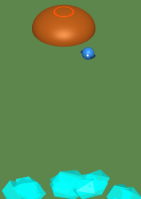

각 단계별 용어와 역할을 암기해주세요!

1. **Orchestrator**
   - 작업 수행 완료를 위해, 필요한 하위작업을 결정합니다.
   - 필요한 개수는 LLM 스스로 조율할 수 있습니다.
2. **Worker**
   - 하위작업 하나를 담당하여, 결과를 만들어냅니다.
   - 어떤 작업을 할지는 Orchestrator에게 전달 받습니다.
3. **Synthesize** (씬서사이즈, 합성)
   - 모든 작업이 끝나기까지 기다린 후, Worker의 결과물을 종합하여 최종 답변을 만들어냅니다.

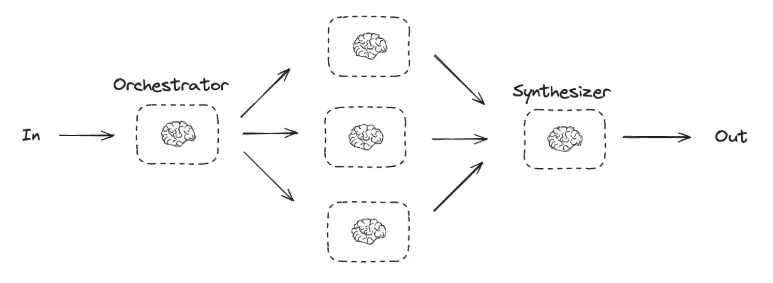

Orchestrator Worker 를 구현하기 위해, 처음으로 사용해야 할 API가 있습니다.
- **Send API** 입니다.
    - Worker 노드를 동적으로 생성한 후, 수행할 명령을 전달합니다.
    - 예시) Send(WorkerNode이름, 전달할명령)


### 예시코드

아래 예시코드의 시나리오는 다음과 같습니다.
  - 책 주제를 입력합니다.
  - Orchestrator는 입력받은 책 주제에 대한 목차를 만듭니다. (2 ~ 5개 챕터로 구성합니다.)
  - 챕터 개수 만큼 Worker Node를 만들고, 각각 챕터의 내용을 완성하게끔 시킵니다.
  - Synthesize는 모든 Worker Node 작업이 종료될 때 까지 기다린 후, 취합하여 최종 책 내용을 만듭니다.

<br/>

특징
 - 각 챕터는 독립적으로 만들어지기에, 이전 챕터의 내용을 알지 못한상태로 내용을 만들게 됩니다.
 - 모든 챕터의 글은 병렬적으로 동시에 만들어집니다.

In [5]:
from typing_extensions import TypedDict, List, Annotated, NotRequired

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

llm = ChatOpenAI(model="gpt-5-nano", api_key=os.getenv("GMS_KEY"), base_url="https://gms.ssafy.io/gmsapi/api.openai.com/v1/", temperature=0)


# ===== Structured Output 준비 =====
class Chapter(BaseModel): 
    name: str = Field(description="챕터의 제목")
    description: str = Field(description="이 챕터에서 다룰 상세 내용과 집필 가이드라인")

class BookPlan(BaseModel): 
    chapters: List[Chapter] = Field(description="책을 구성하는 챕터 리스트")

llm_planner = llm.with_structured_output(BookPlan)


# ===== State 정의 =====
class State(TypedDict):
    topic: str
    chapters: NotRequired[List[Chapter]] # 기획된 챕터 객체들
    completed_chapters: NotRequired[Annotated[list[tuple[int, str]], operator.add]] # (챕터번호, 내용) 저장
    final_report: NotRequired[str]

class WorkerState(TypedDict):
    index: int # 챕터 번호
    chapter: Chapter # 배정된 챕터 객체 (제목 + 가이드라인)
    completed_chapters: Annotated[list[tuple[int, str]], operator.add] # State와 연결용도


## ===== Orchestrator(책 기획을 담당) =====
def orchestrator(state: State):
    topic = state["topic"]
        
    # LLM이 BookPlan 객체를 반환 (Structured Output)
    result = llm_planner.invoke([
        SystemMessage(content="주어진 주제에 대해 2~5개의 챕터로 구성된 전문적인 목차와 집필 계획을 세워라."),
        HumanMessage(content=topic)
    ])
    
    return {"chapters": result.chapters, "completed_chapters": []}


# ====== 병렬 실행 (SendAPI) =====
def assign_workers(state: State):
    return [Send("worker", {"index": i, "chapter": c}) for i, c in enumerate(state["chapters"])]


# ===== worker (책 집필 담당) =====
def worker(state: WorkerState):
    idx = state["index"]
    ch = state["chapter"]

    result = llm.invoke([
        SystemMessage(content="당신은 전문 작가입니다. 제공된 챕터 제목과 가이드라인을 바탕으로 내용을 정확히 3줄로 작성하세요."),
        HumanMessage(content=f"챕터 제목: {ch.name}\n집필 가이드: {ch.description}")
    ])
    
    # 순서 보장을 위해 (인덱스, 내용) 튜플 반환
    return {"completed_chapters": [(idx, result.content)]}


def synthesizer(state: State):
    # 1. 인덱스 번호 순서대로 정렬 (순서 보장)
    sorted_data = sorted(state["completed_chapters"], key=lambda x: x[0])
    
    # 2. 챕터별 내용 취합
    final_contents = []
    full_text_for_title = "" # 제목 생성을 위해 전체 내용을 모을 변수
    
    for idx, content in sorted_data:
        chapter_info = state["chapters"][idx]
        chapter_title = f"## Chapter {idx+1}. {chapter_info.name}"
        section_text = f"{chapter_title}\n\n{content}"
        
        final_contents.append(section_text)
        full_text_for_title += section_text + "\n\n"

    # 3. 전체 내용을 바탕으로 책 제목 생성
    title_result = llm.invoke([
        SystemMessage(content="""작성된 책의 전체 내용을 보고, 독자의 흥미를 끌 수 있는 매력적인 책 제목을 하나만 지어라. 
                      결과는 오직 제목만 출력해라. 따옴표는 제거해라."""),
        HumanMessage(content=f"원래 주제: {state['topic']}\n\n작성된 내용:\n{full_text_for_title}")
    ])
    book_title = title_result.content.strip()

    # 4. 최종 결과물 조립 (제목 + 내용)
    final_report = f"# 제목: {book_title}\n\n" + "\n\n---\n\n".join(final_contents)
    return {"final_report": final_report}

    
# ===== Graph 구성 =====
graph = StateGraph(State)

graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("synthesizer", synthesizer)

graph.add_edge(START, "orchestrator")

# 조건분기 랭그래프
graph.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["worker"],
)

graph.add_edge("worker", "synthesizer")
graph.add_edge("synthesizer", END)

agent = graph.compile()


# === 실행 ===
result = agent.invoke({"topic": "아이언맨과 스파이더맨이 전투를 하는 소설"})

print(result["final_report"])

/opt/conda/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=BookPlan(chapters=[Chapte...습을 보여준다.')]), input_type=BookPlan])
  return self.__pydantic_serializer__.to_python(


# 제목: 아이언맨과 스파이더맨: 오해를 넘어선 연대의 불꽃

## Chapter 1. 오해가 만든 그림자

도시를 무대로 벌어지는 최초의 충돌은 정보의 오류와 음모로 시작된다.
아이언맨과 스파이더맨은 서로의 의도를 오해하고 초능력과 기술에 대한 불신으로 대치를 벌인다.
독자는 두 영웅의 시점을 오가며 충돌의 도덕적 양면과 갈등의 씨앗을 따라간다.

---

## Chapter 2. 하늘과 벽 사이의 충돌

하늘과 벽 사이의 충돌은 아이언맨의 첨단 무기와 스파이더맨의 민첩성으로 시작된다.
네트워크 속도와 물리 법칙이 맞붙으며 도시의 생태계가 흔들리고, 공중전은 기술과 규칙의 진정한 대결로 전개된다.
두 히어로는 상대의 강점에 대응하고 각자의 신념을 시험하며 끝까지 서로를 마주한다.

---

## Chapter 3. 진실의 거짓말 사이

외부 세력이 조작한 증거들이 서로 다른 해석을 낳아 진실과 거짓의 경계를 흔든다.
두 영웅은 서로를 증오에서 벗어나려 애쓰지만 의심은 쉽게 가시지 않는다.
잃어버린 진실을 좇으며 과거의 선택과 현재의 책임이 충돌한다.

---

## Chapter 4. 연대의 불꽃: 한목소리로 맞서다

오해를 풀고 공통의 적을 직시한 아이언맨과 스파이더맨은 서로의 차이를 존중하며 한목소리로 맞선다.
기술과 의지를 합쳐 전투의 흐름을 바꾼 두 영웅은 도시를 구하고, 전투의 상처를 치유하기 위한 협력을 다진다.
연대의 불꽃이 번져 남은 흔적까지 지우며, 한마음의 협력으로 도시를 회복시키는 모습을 보여준다.


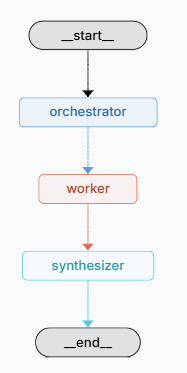

# 3. Plan-and-Execute 패턴 (Sequential Orchestrator worker 패턴)

### Plan-and-Execute 패턴이란?

Orchestrator-Worker 패턴에서 Orchestrator에게 순차적인 작업 Plan을 세우도록 할 수 있습니다.

기존에 다루었던 패턴은 Orchestrator가 작은 작업으로 나누어, 모두 병렬로 일을 하는 구조였습니다.

하지만 음식 레시피의 각 Step을 병렬로 수행하면 안되겠죠!?

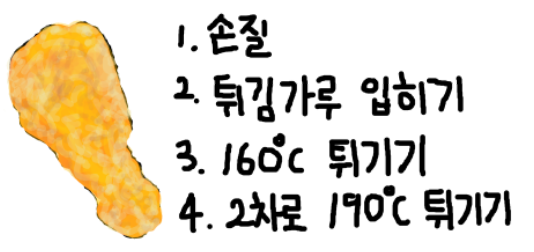

Plan으로 Step1, 2, 3, ... 와 같은 절차를 만들겠습니다.
- LLM이 스스로 Step의 개수와 절차를 결정할 것입니다.

이후 각 절차를 순차적으로 수행합니다.

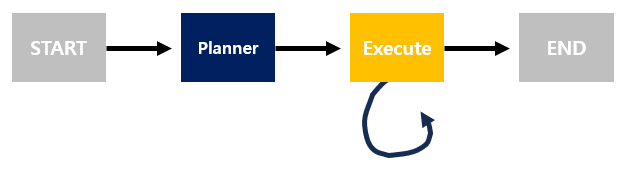

### 예시코드

In [6]:
from typing_extensions import TypedDict, List, Annotated, NotRequired

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

llm = ChatOpenAI(model="gpt-5-nano", api_key=os.getenv("GMS_KEY"), base_url="https://gms.ssafy.io/gmsapi/api.openai.com/v1/", temperature=0)


# ===== Structured Output 준비 =====
class Step(BaseModel):
    title: str = Field(description="이번 Step의 명칭")
    instruction: str = Field(description="이전 결과물을 바탕으로 수행해야 할 구체적인 작업 지침")

class Plan(BaseModel):
    steps: List[Step] = Field(description="음식 제작을 위한 순차적 단계 리스트")

planner_llm = llm.with_structured_output(Plan)


# ===== State =====
class State(TypedDict):
    topic: str # 음식 이름
    steps: NotRequired[List[Step]] # 기획된 Step 객체들
    current_idx: NotRequired[int]  # 몇 번째 단계의 Work인지 확인용 Index
    context: NotRequired[str] # 이전 작업 결과가 누적되는 저장소


# ===== Planner(기획자) =====
def planner(state: State):
    result = planner_llm.invoke([
            SystemMessage(content="주어진 주제를 해결하기 위해 순서가 중요한 2~5단계의 정밀한 계획을 세워라."),
            HumanMessage(content=state["topic"])
        ])
    
    return {
        "steps": result.steps,
        "current_idx": 0,
        "context": "--- [조리 시작] ---"
    }


# ===== Execute Node (직렬 실행) =====
def execute_step(state: State):
    curr_idx = state["current_idx"]
    step_info = state["steps"][curr_idx]
    
    # 이전 단계의 context를 참고하여 현재 단계를 수행
    response = llm.invoke([
        SystemMessage(content=f"당신은 전문 요리사입니다. 이전까지의 과정을 바탕으로 다음 단계를 완성하세요."),
        HumanMessage(content=f"""
[지금까지 진행된 상황]:
{state['context']}

[이번에 수행할 작업]:
단계명: {step_info.title}
상세 지침: {step_info.instruction}

위 지침에 따라 결과를 3줄 내외로 작성하세요.
""")
    ])
    
    # 생성된 결과 누적
    step_result = f"\n\n### {curr_idx + 1}. {step_info.title}\n{response.content}"
    
    return {
        "context": state["context"] + step_result,
        "current_idx": curr_idx + 1
    }


# ===== 종료 조건 확인 =====
def should_continue(state: State):
    # Orchestrator가 기획한 Step 개수가 넘어가면 종료
    if state["current_idx"] < len(state["steps"]):
        return "execute_step"
    return END


# ===== Graph 구성 =====
graph = StateGraph(State)

graph.add_node("planner", planner)
graph.add_node("execute_step", execute_step)

graph.add_edge(START, "planner")
graph.add_edge("planner", "execute_step")

# 조건분기 랭그래프
graph.add_conditional_edges(
    "execute_step",
    should_continue,
    {
            "execute_step": "execute_step",
        END: END
    }
)
agent = graph.compile()


# ===== 실행 =====
result = agent.invoke({"topic": "KFC 스타일 프라이드 치킨 레시피"})
print(result["context"])

/opt/conda/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=[Step(title='...바로 서빙한다.')]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


--- [조리 시작] ---

### 1. 재료 준비 및 마리네이드
닭고기를 뼈와 두께 차이에 따라 원하는 부위로 자른다.
큰 볼에 버터밀크 2컵, 소금 1½작은술, 흑후추 약간, 핫소스 1~2작은술을 섞고 닭고기를 2~4시간(가능하면 냉장 overnight) 마리네이드한다.
마리네이드 도중 한두 번 뒤집어 골고루 배이도록 한다.

### 2. 건식 스파이스 블렌드 만들기
큰 볼에 다목적 밀가루 2컵, 옥수수 전분 ½컵, 파프리카 1–2큰술, 마늘가루 1큰술, 양파가루 1큰술, 소금 1작술, 흑후추 1작술, 화이트 페퍼 ½작술, 칠리 파우더 ½작술, 건타임 1작술, 건오레가노 1작술, 설탕 1작술을 넣고 골고루 섞어 바삭한 코팅용 스파이스 블렌드를 만든다.
마리네이드된 닭고기에 이 건식 스파이스 블렌드를 입혀 바삭한 표면 코팅을 준비한다.
필요 시 코팅은 손으로 살짝 눌러 밀착시키고 남은 블렌드는 밀폐 용기에 보관한다.

### 3. 닭고기 코팅하기
- 닭고기를 마리네이드에서 꺼내 표면의 수분을 키친타월로 꼼꼼히 닦아낸다.
- 준비한 건식 스파이스 블렌드를 고르게 묻혀 손으로 살짝 눌러 코팅을 밀착시킨다.
- 원하면 한 차례 더 코팅해 두꺼운 크러스트를 얻는다.

### 4. 튀김 및 마무리
- 180°C로 예열한 기름에 닭고기를 배치별로 담아 한 번에 너무 많이 넣지 말고 튀긴다.
- 가슴살은 12–15분, 다리/날개는 14–18분 정도 노릇하게 황금갈색이 되고 내부 온도 74°C(165°F) 이상에 도달하면 건져 기름기를 빼낸다.
- 랙 위에서 5분 휴지한 뒤 바로 서빙한다.


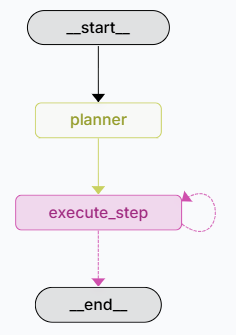

### [참고] Orchestrator-Workers 패턴은, Agent Workflow의 공식 명칭이 맞나요?

참고로 Agent Workflow 패턴들의 명칭은 통일되지 않았습니다.
  - 암묵적으로는... 구글, OpenAI, 엔트로픽(클로드)에서 공식 기술자료를 만들어 용어를 사용하면, 그게 공식 명칭으로 간주 되는것이죠.

LangGraph에서는 Plan-and-Execute라는 이름을 썼었고 (지금은 기술 블로그 내용이 삭제되었어요.)

엔트로픽은 순차적으로 실행하는 것도 Orchestrator-Workers 패턴으로 취급하곤 합니다.
  - https://platform.claude.com/cookbook/patterns-agents-orchestrator-workers

지금까지 순차적으로 Plan을 세워서 실행하는 패턴을 학습했습니다.

# 4. Evaluator-Optimizer 패턴

### Evaluator-Optimizer 패턴이란?

Evaluator-Optimizer는 LLM에게 평가자를 붙여서, 성능을 개선시키는 방법입니다.

사례를 보도록 하겠습니다.

아래 그림과 같이 Workflow를 구성했지만, 간헐적으로 LLM이 답변을 잘 수행 못하는 경우가 있습니다.

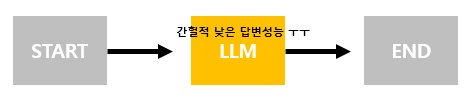

이런 경우 LLM이 그대로 답변하는 것이 아니라,

평가해주는 LLM을 추가로 붙여주면 일관된 답변 품질을 유지할 수 있습니다.

  - Optimizer가 제대로 답변했는지 Evaluator가 확인합니다.
  - 제대로 답변했다면 그대로 답변을 제출합니다.
  - 마음에 들지 않는다면, 피드백과 함께 다시 답변을 시킵니다.

간단하죠?

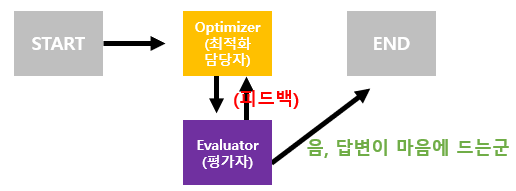

Optimizer가 만든 질문을, Evaluator가 계속 마음에 안든다고 하면 어떻게 하나요?

최대 피드백 횟수를 정해두면 됩니다.

최대 피드백을 넘어가면 어쩔수없이 마지막 답변을 전달합니다.

### 다양한 용어

이 용어는 LangGraph / Claude 모두 쓰는 용어입니다.
  - https://claude.com/blog/common-workflow-patterns-for-ai-agents-and-when-to-use-them
  - https://docs.langchain.com/oss/python/langgraph/workflows-agents
  - 구 이름은 "Reflection 패턴" 입니다.

### Evaluator-Optimizer 장점과 단점

장점
  - LLM 품질이 일관되게 나올 수 있습니다.

단점
  - LLM 사용비용이 배로 나와요.
  - 답변이 마음에 안들어 Loop를 돌 때 마다 시간이 소요됩니다.

꼭 중요한 곳에만 쓰면 되겠죠?

### Evaluator 모델은 Optimizer 보다 성능이 더 좋은 모델을 써야하나요?

- 비용만 허락한다면, 그러는 것이 좋습니다.
  - 보통 출력토큰보다 입력 토큰비용이 저렴하기 때문에, 비용 계산해서 선택하시면 될겁니다.
- 비용을 아끼려면, 같은 성능의 모델을 써도 됩니다.

### 코드 분석하기 (Loop 제한 없는 코드)

입력받은 주제에 대해 농담을 만들어내는 LLM 입니다.

재미있는 얘기로 평가될 때 까지 Optimizer는 지속적으로 새로운 농담을 만들어냅니다.

In [9]:
from typing_extensions import TypedDict, List, Annotated, NotRequired
from typing import Literal

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv() # .env파일에서 환경설정 가져오기

llm = ChatOpenAI(model="gpt-5-nano", api_key=os.getenv("GMS_KEY"), base_url="https://gms.ssafy.io/gmsapi/api.openai.com/v1/", temperature=0)


# ===== State =====
class State(TypedDict):
    topic: str
    joke: NotRequired[str]
    feedback: NotRequired[str]
    funny_or_not: NotRequired[str]


# ===== Structured Output 준비 =====
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재밌는지, 재미가 없는지 결정한다.",
    )
    feedback: str = Field(
        description="농담이 재미 없는 경우, 어떻게 하면 더 재미있을지 피드백을 제공한다.",
    )
    
llm_evaluator = llm.with_structured_output(Feedback)


# ===== Generator(Optimizer) Node =====
def llm_call_generator(state: State):    
    prompt = f"{state['topic']}에 관련되어 웃긴 농담 1개만 해줘 (3줄 이내)\n"
    
    if state.get("feedback"):
        prompt += f"이전에 너가 시도했던 농담의 피드백인데, 반영해줘 : {state['feedback']}"

    result = llm.invoke(prompt)
    return {"joke": result.content}


# ===== Evaluator Node =====
def llm_call_evaluator(state: State):
    grade = llm_evaluator.invoke(f"다음 농담에 대해 재미있는지 판별해줘 : {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# ===== 조건 분기 ======
def route_joke(state: State):
    if state["funny_or_not"] == "funny":
        return "Accepted"

    return "Rejected + Feedback"


# ===== Graph 생성 =====
graph = StateGraph(State)

graph.add_node("generator", llm_call_generator)
graph.add_node("evaluator", llm_call_evaluator)

graph.add_edge(START, "generator")
graph.add_edge("generator", "evaluator")

# 조건분기 랭그래프
graph.add_conditional_edges(
    "evaluator",
    route_joke,
    {
        "Accepted":END,
        "Rejected" + "Feedback": "generator",
    }
)

agent = graph.compile()

state = agent.invoke({"topic": "KFC 햄버거"})
print(state["joke"])

KFC 햄버거를 들고 걷고 있는데 친구가 물었어.
"그 안에 닭이 숨어 있니?"
대답했지: "아니, 오늘은 빵이 주연이고 패티가 보조 배우야."


/opt/conda/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Feedback(grade='funny', f... 것도 좋습니다.'), input_type=Feedback])
  return self.__pydantic_serializer__.to_python(


### 제한 반복 횟수를 추가한 코드

무한루프를 방지하기 위해 제한 반복횟수를 추가하였습니다.

In [10]:
from typing_extensions import TypedDict, List, Annotated, NotRequired
from typing import Literal

from pydantic import BaseModel, Field
import operator
import os

from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from dotenv import load_dotenv

# ===== LLM =====
load_dotenv()  # .env파일에서 환경설정 가져오기

llm = ChatOpenAI(model="gpt-5-nano", api_key=os.getenv("GMS_KEY"), base_url="https://gms.ssafy.io/gmsapi/api.openai.com/v1/", temperature=0)


# ===== State =====
class State(TypedDict):
    topic: str
    joke: NotRequired[str]
    feedback: NotRequired[str]
    funny_or_not: NotRequired[str]
    iteration: NotRequired[int]


# ===== Structured Output =====
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재밌는지, 재미가 없는지 결정한다.",
    )
    feedback: str = Field(
        description="농담이 재미 없는 경우, 어떻게 하면 더 재미있을지 피드백을 제공한다.",
    )


llm_evaluator = llm.with_structured_output(Feedback)

# ===== Init Node =====
def initialize(state: State):
    return {
        "iteration": 0
    }


# ===== Generator(Optimizer) Node =====
def llm_call_generator(state: State):
    prompt = f"{state['topic']}에 관련되어 웃긴 농담 1개만 해줘 (3줄 이내)\n"

    if state.get("feedback"):
        prompt += f"이전에 너가 시도했던 농담의 피드백인데, 반영해줘 : {state['feedback']}"

    result = llm.invoke(prompt)

    return {
        "joke": result.content,
        "iteration": state["iteration"] + 1  # 반복 증가
    }


# ===== Evaluator =====
def llm_call_evaluator(state: State):
    grade = llm_evaluator.invoke(f"다음 농담에 대해 재미있는지 판별해줘 : {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# ===== Router =====
def route_joke(state: State):
    # 1. 성공 조건
    if state["funny_or_not"] == "funny":
        return "Accepted"

    # 2. 반복 횟수 초과 (3회 제한)
    if state["iteration"] >= 3:
        return "Max Iteration Reached"

    # 3. 다시 생성
    return "Rejected + Feedback"


# ===== Graph 생성 =====
graph = StateGraph(State)

graph.add_node("initialize", initialize) # 초기화 노드
graph.add_node("generator", llm_call_generator)
graph.add_node("evaluator", llm_call_evaluator)

graph.add_edge(START, "initialize")
graph.add_edge("initialize", "generator")
graph.add_edge("generator", "evaluator")

graph.add_conditional_edges(
    "evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "generator",
        "Max Iteration Reached": END,
    },
)

agent = graph.compile()

# ===== 실행 =====
result = agent.invoke({
    "topic": "KFC 햄버거"
})

print(result["joke"])
print()
print("[Feedback]")
print(result["feedback"])
print()
print("iteration:", result["iteration"])
print("result:", result["funny_or_not"])

KFC 햄버거를 한 입에 베어 물었더니, 바삭함이 내 일상을 점령했다.
친구가 웃으며 묻는다. “닭이 햄버거 안에 들어간 거야?”
나는 대답한다. “응, 바삭함이 우리 신입 직원으로 승진했지.”

[Feedback]
이 농담은 바삭함을 의인화해 신입사원 승진으로 연결하는 간단한 말장난으로 구성되어 있습니다. 전개가 짧고 상황 설정이 명확해 웃음 포인트가 분명합니다. KFC 맥락과 의외의 결말이 가볍고 재치있게 다가옵니다. 다만 유머의 강도는 청중에 따라 달라질 수 있어, 더 강한 반전이나 더 명확한 단서로 트릭을 끌끌끌어올리면 더 크게 웃음을 이끌 수도 있습니다.

iteration: 1
result: funny


/opt/conda/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Feedback(grade='funny', f... 수도 있습니다.'), input_type=Feedback])
  return self.__pydantic_serializer__.to_python(


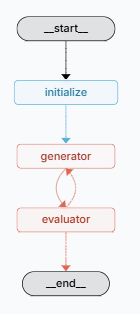

### 미션 - Workflow 개발
  - Workflow를 어떻게 구현할지 설계해보세요.
  - Orchestrator-Worker 패턴을 사용해주세요.
  - 최종 결과를 취합하는 LLM에 Evaluator-Optimizer 패턴을 적용해주세요.

# 8. 끝으로

- 고생하셨습니다. 드디어 Agent Workflow 마무리가 되었습니다.
- 지금까지 살펴본 Agent Workflow는 다음과 같습니다.


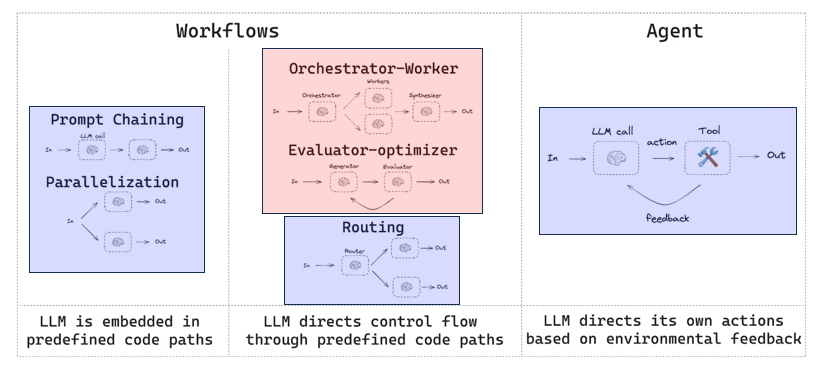

- 함께 살펴본 Workflow 패턴과 Gradio UI를 사용하면, 여러분만의 AI 서비스를 개발할 수 있을 것입니다!

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.